# CW1 - Multimodal Classification of New York Times News Sections Using Images and Captions with Keras

## Introduction

In this assignment you will be provided a dataset containing a selection of images in JPEG image format and together with their caption in text format from articles appearing on the web site of the New York Times.


![Example](https://i.ibb.co/67v6LVV8/Screenshot-2025-09-11-151406.png)


You will be analysing this dataset by implementing and training two models: a **CNN** and an **LSTM**.

The CNN must classify images by the section they appear in. Independently, the LSTM must classify images captions by the section. Finally, you will evaluate and critically comment your results in a short report. Use the Google Colab notebook provided, and prepare a 2-3 pages report that critically evaluates the model. (Which of the two modalities was better for classifying images?)

## Structure of the assignment

This assignment is broken up into sections and you need to complete each section successively. The sections are the following:

1. Data Processing

  1.a. Image processing of the images

  1.b. Natural language processing of the captions

2. Models Definition

  2.a. CNN for the images

  2.b. LSTM for the captions

3. Models Training
4. Models Evaluation

In addition to this coding exercise, you must write a **2-page** report analysing and critically evaluating your model's results. Marks for the report will be awarded for depth of analysis and critical thinking skills. You should consider how well your model performs and WHY it does that—give specific examples and comment on their importance.

In [1]:
# Enter your module imports here, many modules are already provided

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import pathlib
import pandas as pd
import tarfile
from tensorflow import keras
from pathlib import Path
from sklearn import model_selection
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.metrics import Precision, Recall
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense

In [2]:
# CodeGrade Tag Init1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Processing



In [4]:
# CodeGrade Tag Init2
# Do not edit, remove, or copy this cell

DATA_TAR  = Path("/content/drive/MyDrive/Multimodal_NYT_dataset.tar")
DATA_ROOT = Path("./Multimodal_NYT_dataset")
IMAGES_DIR = DATA_ROOT / "NYT_imgs"
CSV_PATH   = DATA_ROOT / "NYT_dataset.csv"

# Error message if Multimodal_NYT_dataset.tar not found
assert DATA_TAR.exists(), "Please, upload Multimodal_NYT_dataset.tar to Google Drive in MyDrive"

if not DATA_ROOT.exists():
    with tarfile.open(DATA_TAR, "r:") as tarf:
        tarf.extractall(path=".")
    print(f"Extracted {DATA_TAR.name}")

# Error message if NYT_imgs/ and NYT_dataset.csv not found in the tar file
assert IMAGES_DIR.exists() and CSV_PATH.exists(), "Multimodal_NYT_dataset.tar must contain NYT_imgs/ and NYT_dataset.csv"

print("Staging complete.")

/tmp/ipython-input-166472130.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tarf.extractall(path=".")


Extracted Multimodal_NYT_dataset.tar
Staging complete.


In [5]:
# CodeGrade Tag Init3
# Do not edit, remove, or copy this cell

DATA_ROOT  = Path("./Multimodal_NYT_dataset")
CSV_PATH   = DATA_ROOT / "NYT_dataset.csv"
IMAGES_DIR = DATA_ROOT / "NYT_imgs"
ID_COL     = "image_id"

assert CSV_PATH.exists(), f"CSV not found at {CSV_PATH}."
assert IMAGES_DIR.exists(), f"Images folder not found at {IMAGES_DIR}."


### 1.a. Image processing of the images

* **Load the dataset from the path ``CSV_PATH`` by using pd.read_csv and split it into training and testing with test size 20%**


In [6]:
import pandas as pd
from sklearn import model_selection

# CodeGrade Tag Ex1a-i
### Load the dataset from the path CSV_PATH by using pd.read_csv and split it
### into training and testing with test size 20%

dataset = pd.read_csv(CSV_PATH)
#Complete here
data_train, data_test = model_selection.train_test_split(dataset,test_size=0.2,random_state=42)
#Complete here


* **Use a OneHotEncoder to convert the target feature ''section'' into numeric One-Hot labels. Then, as a sanity check, count the number of different sections and save it in ``sections_number``** (the result has to be 24).

In [7]:
# CodeGrade Tag Ex1a-ii
### Use a OneHotEncoder to convert the target feature ''section'' into numeric
### One-Hot labels. Then, as a sanity check, count the number of different
### sections and save it in ``sections_number``** (the result has to be 24)

sections_all = np.array(sorted(dataset["section"].dropna().unique()))

ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
    #Complete here
ohe.fit(sections_all.reshape(-1,1))

labels_train = ohe.transform(data_train["section"].values.reshape(-1,1))
#Complete here
labels_test  = ohe.transform(data_test["section"].values.reshape(-1,1))
#Complete here

sections_names  = ohe.get_feature_names_out(["section"])

sections_number = len(sections_names)
#Complete here

In [8]:
# CodeGrade Tag Init4
# Do not edit, remove, or copy this cell

# Obtain clean captions with NaN-free string ndarrays
captions_train = pd.Series(data_train["caption"], dtype="object").fillna("").astype(str).to_numpy()
captions_test  = pd.Series(data_test["caption"],  dtype="object").fillna("").astype(str).to_numpy()

# Index the images folder
allowed_exts = {".jpg", ".jpeg", ".png", ".jfif", ".webp"}
img_index = {}
for p in IMAGES_DIR.iterdir():
    if p.is_file() and p.suffix.lower() in allowed_exts:
        img_index[p.stem] = str(p)

print(f"Indexed {len(img_index):,} images from {IMAGES_DIR}")

# Remap IDs to existing files (and drop rows with missing images)
def remap_paths(frame, labels, captions, *, id_col=ID_COL):
    ids = frame[id_col].astype(str).str.strip().to_numpy()
    mask = np.array([i in img_index for i in ids])
    dropped = int((~mask).sum())
    if dropped:
        missing_ids = [ids[i] for i in np.where(~mask)[0][:3]]
        print(f"Dropping {dropped} rows with missing images.")
    paths = np.array([img_index[i] for i in ids[mask]], dtype=object)
    labels = labels[mask].astype("float32")
    captions = captions[mask]
    frame = frame.iloc[np.where(mask)[0]].reset_index(drop=True)

    return frame, paths, labels, captions

data_train, img_locs_train, labels_train, captions_train = remap_paths(
    data_train, labels_train, captions_train
)
data_test,  img_locs_test,  labels_test,  captions_test  = remap_paths(
    data_test,  labels_test,  captions_test
)

# Report final sample counts
print(f"Final sizes — train: {len(img_locs_train)}, validation: {len(img_locs_test)}")

Indexed 61,407 images from Multimodal_NYT_dataset/NYT_imgs
Dropping 6 rows with missing images.
Dropping 2 rows with missing images.
Final sizes — train: 48968, validation: 12242


In [9]:
# CodeGrade Tag Init5
# Do not edit, remove, or copy this cell

# This function is provided to read in the image files from the folder
def parse_image(filename, label):
    img = tf.io.read_file(filename)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])  # static shape for tf.data
    return img, label

In [10]:
# CodeGrade Tag Init6
# Do not edit, remove, or copy this cell

# Create the initial datasets of images
list_images_train_ds = tf.data.Dataset.from_tensor_slices(
    (img_locs_train, labels_train.astype("float32"))
)
list_images_valid_ds = tf.data.Dataset.from_tensor_slices(
    (img_locs_test, labels_test.astype("float32"))
)

* **Create a function called ```img_resize``` converts the images to float32 datatype and resizes them to 128x256 pixels.**

In [11]:
# CodeGrade Tag Ex1a-iii
### Write a function call img_process that resizes the image to 128x256, and
### converts the data type of the images to tf.float32

def img_process(image, label):
    #Complete here
    image=tf.image.resize(image,(128,256))
    image=tf.cast(image,tf.float32)
    return image, label

* **Using the ``tf.data`` API, load in the training and validation data for the images. Be mindful of efficient data processing good practice to minimise the time it takes to load the data.**

In [28]:
from numpy.random import shuffle
# CodeGrade Tag Ex1a-iv
### Use the parse_image and img_process functions to construct the training and
### validation datasets. You should utilise good practice in optimising the
### dataset loading. Use a batch size of 32.
batch_size=32
imagess_train_ds = tf.data.Dataset.from_tensor_slices((img_locs_train,labels_train)).map(
    parse_image,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).map(
    img_process,num_parallel_calls=tf.data.AUTOTUNE).cache().shuffle(
    buffer_size=1000).prefetch(tf.data.AUTOTUNE)
#Complete here


images_valid_ds = tf.data.Dataset.from_tensor_slices((img_locs_test,labels_test)).map(
    parse_image,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).map(
    img_process,num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)
#Complete here


AttributeError: '_ParallelMapDataset' object has no attribute 'catche'

### 1.b. Natural Language processing of the captions

* Build the vocabulary of the model by calling the ``encoder.adapt()`` method on the captions train data. Make sure the output sequence lenght is fixed and it is ``SEQ_LEN``.

In [13]:
# CodeGrade Tag Ex1b-i
### Build the vocabulary of the model by calling the encoder.adapt() method on
### the captions train data. Make sure the output sequence lenght is fixed and
### it is SEQ_LEN.

VOCAB_SIZE = 10000
SEQ_LEN = 200

encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQ_LEN
)
#Complete here
encoder.adapt(captions_train)
#Complete here

* Print the first 200 words of the vocabulary you obtained.

In [14]:
# CodeGrade Tag Ex1b-ii
### Print the first 200 words of the vocabulary you obtained.
vocab_list = encoder.get_vocabulary()
print(vocab_list[:200])

['', '[UNK]', np.str_('the'), np.str_('in'), np.str_('a'), np.str_('of'), np.str_('and'), np.str_('at'), np.str_('to'), np.str_('on'), np.str_('for'), np.str_('from'), np.str_('with'), np.str_('is'), np.str_('new'), np.str_('by'), np.str_('left'), np.str_('an'), np.str_('that'), np.str_('his'), np.str_('as'), np.str_('was'), np.str_('has'), np.str_('her'), np.str_('said'), np.str_('he'), np.str_('this'), np.str_('will'), np.str_('its'), np.str_('it'), np.str_('are'), np.str_('be'), np.str_('who'), np.str_('which'), np.str_('york'), np.str_('their'), np.str_('one'), np.str_('center'), np.str_('have'), np.str_('last'), np.str_('after'), np.str_('president'), np.str_('she'), np.str_('about'), np.str_('but'), np.str_('during'), np.str_('theater'), np.str_('home'), np.str_('been'), np.str_('more'), np.str_('city'), np.str_('had'), np.str_('first'), np.str_('year'), np.str_('right'), np.str_('show'), np.str_('not'), np.str_('company'), np.str_('trump'), np.str_('were'), np.str_('years'), np.

* **Using the ``tf.data`` API, load in the training and validation data for the captions.**

In [15]:
# CodeGrade Tag Ex1b-iii

# Encode the captions with the TF encoder and cast token IDs to int32
captions_train_ids = tf.cast(encoder(tf.constant(captions_train, dtype=tf.string)), tf.int32)
captions_test_ids  = tf.cast(encoder(tf.constant(captions_test,  dtype=tf.string)), tf.int32)

# Build datasets by pairing encoded captions with their labels
captions_train_ds_raw = tf.data.Dataset.from_tensor_slices((captions_train_ids, labels_train))
captions_valid_ds_raw = tf.data.Dataset.from_tensor_slices((captions_test_ids,  labels_test))

### Construct the training and validation datasets. You should utilise good
### practice in optimising the dataset loading. Use a batch size of 128.
batch_size=128
captions_train_ds = (captions_train_ds_raw.shuffle(buffer_size=1000).batch(
    batch_size).prefetch(tf.data.AUTOTUNE)
)
#Complete here

captions_valid_ds = (captions_train_ds_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)
)
#Complete here

# 2. Models Definition

### 2.a. CNN

**Using the Keras Functional API, create a convolutional neural network with the architecture show in the model summary below.**

**A few important points to consider:**

* Call the convolutional layers and the first dense layer should have ReLU activation functions. The output layer should have a Sigmoid activation function.
* Pay attention to the output shapes and the number of partmeters for each layer, as these give indications as to the correct settings for the number of filters, kernel size, stride length and padding.
* Use the layer names provided in the summary in your model.
* For the dropout layers, use a dropout rate of 0.2 after the convolutional layers and 0.5 after the dense layers.


```
# Model Summary

 Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv0 (Conv2D)                  │ (None, 64, 128, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop1 (Dropout)                 │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 64, 128, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 128, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop2 (Dropout)                 │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 32, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 32, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop3 (Dropout)                 │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv5 (Conv2D)                  │ (None, 16, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv6 (Conv2D)                  │ (None, 16, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop4 (Dropout)                 │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool4 (MaxPooling2D)            │ (None, 4, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flat (GlobalAveragePooling2D)   │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop5 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop6 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 24)             │        12,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 637,272 (2.43 MB)
 Trainable params: 637,272 (2.43 MB)
 Non-trainable params: 0 (0.00 B)


```



In [16]:
# CodeGrade Tag Ex2a-i
### Define the model using the Keras Functional API. Use the summary above as a
### guide for the model parameters. You will need to define the filters/units of
### the layers correctly, as well as the kernel size, stride length and padding
### of the convolutional layers.

def build_cnn_model():

  #Complete here
  inputs = tf.keras.Input(shape=(128, 256, 3),name="Input")
  x = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu", name="Conv0")(inputs)
  x = tf.keras.layers.Dropout(0.2, name="Drop1")(x)
  x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="Conv1")(x)
  x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="Conv2")(x)
  x = tf.keras.layers.Dropout(0.2, name="Drop2")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2, name="Pool1")(x)

  x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", name="Conv3")(x)
  x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", name="Conv4")(x)
  x = tf.keras.layers.Dropout(0.2, name="Drop3")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2, name="Pool2")(x)

  x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="Conv5")(x)
  x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="Conv6")(x)
  x = tf.keras.layers.Dropout(0.2, name="Drop4")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2, name="Pool3")(x)
  x = tf.keras.layers.MaxPooling2D(pool_size=2, name="Pool4")(x)

  x = tf.keras.layers.GlobalAveragePooling2D(name="Flat")(x)

  x = tf.keras.layers.Dense(512, activation="relu", name="FC1")(x)
  x = tf.keras.layers.Dropout(0.5, name="Drop5")(x)
  x = tf.keras.layers.Dense(512, activation="relu", name="FC2")(x)
  x = tf.keras.layers.Dropout(0.5, name="Drop6")(x)
  outputs = tf.keras.layers.Dense(24, activation="sigmoid",name="Output")(x)

  model=tf.keras.Model(inputs,outputs,name="functional")
  return model

cnn_model = build_cnn_model()
#Complete here


* Print the model summary and confirm is has the same architecture as the one provided.

In [17]:
# CodeGrade Tag Ex2a-ii
### Print the model summary and confirm is has the same architecture as the one
### provided.
print(cnn_model.summary())
print("The CNN architecture matches the provided summary.")
#Complete here

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,876,888 (64.38 MB)

 Trainable params: 16,876,888 (64.38 MB)

 Non-trainable params: 0 (0.00 B)

* **Compile the model using the Adam Optimizer with a learning rate of ```1e-4``` and ```binary crossentropy``` loss function. For the metrics, use the ``Precision`` and ``Recall`` functions.**

In [18]:
# CodeGrade Tag Ex2a-iii
### Compile the model using the Adam Optimizer with a learning rate of 1e-4 and
### binary crossentropy loss function. For the metrics, use the Precision and
### Recall functions.
cnn_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = [
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
#Complete here

### 2.b. LSTM model

* Set up the embedding layer by using ```tf.keras.layers.Embedding```. The ```input_dim``` is the length of the vocab, and the ```output_dim``` must be **192**. You should also set ```mask_zero=False```.

In [19]:
# CodeGrade Tag Ex2b-i
### Set up the embedding layer. The input_dim is the length of the vocab, and
### the output_dim must be 192. You should also set mask_zero=False.

embedder = tf.keras.layers.Embedding(
    input_dim = len(encoder.get_vocabulary()),
    output_dim = 192,
    mask_zero = False
)#Complete here

* Use ```tf.keras.Sequential``` to build a keras sequential model, with the following layers:


  1.   embedder
  2.   SpatialDropout1D layer with rate 0.2
  3.   BiLSTM layer with 256 units, dropout 0.2, recurrent dropout 0.0 (make sure to use the right ```return_sequences``` parametre to be able to stack this layer with the following BiLSTM)
  4.   BiLSTM layer with 128 units, dropout 0.2, recurrent dropout 0.1
  5.   dense layer with 128 units and relu activation function
  6.   dropout with rate 0.4
  7.   dense output layer with 24 units and sigmoid activation function



In [20]:
# CodeGrade Tag Ex2b-ii
### Build a keras sequential model, with the layers provided above.

lstm_model = tf.keras.Sequential([
    embedder,
    tf.keras.layers.SpatialDropout1D(rate=0.2),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            units=256,
            dropout=0.2,
            recurrent_dropout=0.0,
            return_sequences=True)),
tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            units=128,
            dropout=0.2,
            recurrent_dropout=0.1)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(24, activation="sigmoid")
])
#Complete here
lstm_model
#Complete here

<Sequential name=sequential, built=False>

* Print the model summary and confirm is has the same architecture as the outline provided above.

In [21]:
# CodeGrade Tag Ex2b-iii
### Print the model summary and confirm is has the same architecture as the
### outline provided above.
lstm_model.summary()
#Complete here

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

* Compile the model with binary crossentropy loss, the adam optimizer, and the accuracy metric

In [22]:
# CodeGrade Tag Ex2b-iv
### Compile the model with binary crossentropy loss, the adam optimizer, and
### the accuracy metric
lstm_model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)
#Complete here

# 3. Models Training

* **Create a Model Checkpoint Callback that saves the weights of the best performing epoch, based on the validation loss.**

In [23]:
# CodeGrade Tag Ex3a-i
### Create a ModelCheckpoint callback to store the bext weights from the model,
### based on the validation accuracy. Call this callback "checkpoint_callback"

checkpoint_cnn_filepath = '/content/checkpoint_cnn.weights.h5'
checkpoint_lstm_filepath = '/content/checkpoint_lstm.weights.h5'

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cnn_callback = ModelCheckpoint(
    filepath = checkpoint_cnn_filepath,
    monitor = 'val_loss',
    save_best_only = True,
    save_weights_only = True,
    mode = 'max'
)
#Complete here

checkpoint_lstm_callback = ModelCheckpoint(
    filepath = checkpoint_lstm_filepath,
    monitor = 'val_loss',
    save_best_only = True,
    save_weights_only = True,
    mode = 'min'
)
#Complete here


* **Create a Learning Rate Scheduler Callback that utilises the provided function to decrease the learning rate during training.**

In [24]:
# CodeGrade Tag Ex3a-ii
### Using the function provided, create a LearningRateScheduler callback, call
### it "lr_callback"

def scheduler(epoch, lr):
    if epoch < 10:
        return float(lr)
    else:
        return float(lr * tf.math.exp(-0.01))

lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler)
#Complete here


### 3.a. CNN training

* **Train the CNN model for 25 epochs** (this may take several minutes), **using the callbacks you made previously. Store the losses and metrics to use later.**

In [25]:
# CodeGrade Tag Ex3a-iii
### Train the model for 25 epochs, using the callbacks you have created. Store
### the losses and metrics in a history object.

cnn_history = cnn_model.fit(
    imagess_train_ds,
    validation_data = images_valid_ds,
    epochs = 25,
    callbacks = [checkpoint_cnn_callback, lr_callback]
)
#Complete here

Epoch 1/25
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5217 - precision: 0.2811 - recall: 0.0337

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


1531/1531 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - loss: 0.5215 - precision: 0.2812 - recall: 0.0337 - val_loss: 0.1417 - val_precision: 0.6384 - val_recall: 0.0701 - learning_rate: 1.0000e-04
Epoch 2/25
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - loss: 0.1283 - precision: 0.7075 - recall: 0.1448 - val_loss: 0.1449 - val_precision: 0.4921 - val_recall: 0.1251 - learning_rate: 1.0000e-04
Epoch 3/25
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - loss: 0.1018 - precision: 0.8206 - recall: 0.3228 - val_loss: 0.1558 - val_precision: 0.4137 - val_recall: 0.1526 - learning_rate: 1.0000e-04
Epoch 4/25
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 69s 45ms/step - loss: 0.0707 - precision: 0.8909 - recall: 0.5713 - val_loss: 0.1954 - val_precision: 0.3209 - val_recall: 0.1897 - learning_rate: 1.0000e-04
Epoch 5/25
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - loss: 0.0438 - precision: 0.9418 - recall: 0.7878 - val_loss: 0.2479 - val_precision: 0.2825 - val_recall: 0.2069 - learning_rate: 1.0000e-04
Epoch 6/25


* **Train the model for 10 epochs** (this may take several minutes)**, using the callbacks you made previously. Store the losses and metrics to use later.**

In [26]:
# CodeGrade Tag Ex3b-i
# Train the model for 10 epochs.
lstm_history = lstm_model.fit(
    captions_train_ds,
    validation_data = captions_valid_ds,
    epochs = 10,
    callbacks = [checkpoint_lstm_callback, lr_callback]
)
#Complete here

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.0528 - loss: 0.2220 - val_accuracy: 0.1280 - val_loss: 0.1604 - learning_rate: 0.0010
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 576s 2s/step - accuracy: 0.1318 - loss: 0.1608 - val_accuracy: 0.2972 - val_loss: 0.1326 - learning_rate: 0.0010
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 578s 2s/step - accuracy: 0.2994 - loss: 0.1340 - val_accuracy: 0.4884 - val_loss: 0.1035 - learning_rate: 0.0010
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 617s 1s/step - accuracy: 0.4669 - loss: 0.1111 - val_accuracy: 0.6014 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 573s 1s/step - accuracy: 0.5668 - loss: 0.0955 - val_accuracy: 0.6628 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 605s 2s/step - accuracy: 0.6255 - loss: 0.0844 - val_accuracy: 0.7057 - val_loss: 0.0658 - learning_rate: 0.0010
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 645s 2s/step - accuracy: 0.6614 - loss: 0.

# 4. Models Evaluation

### 4.a. CNN Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

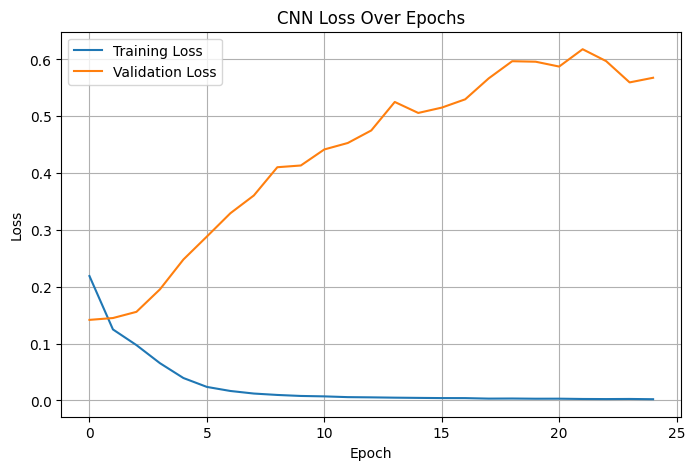

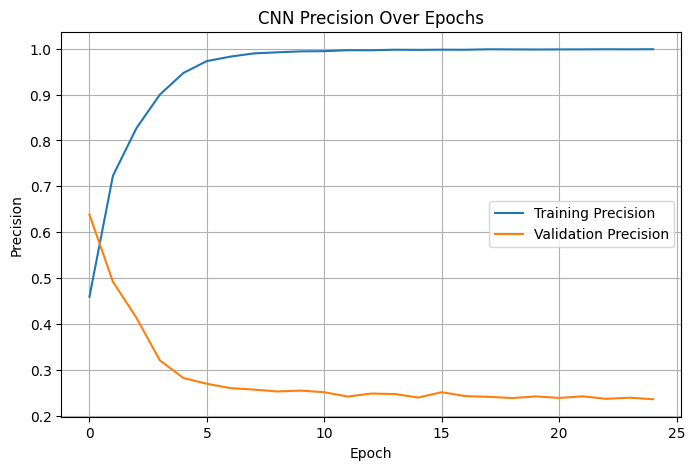

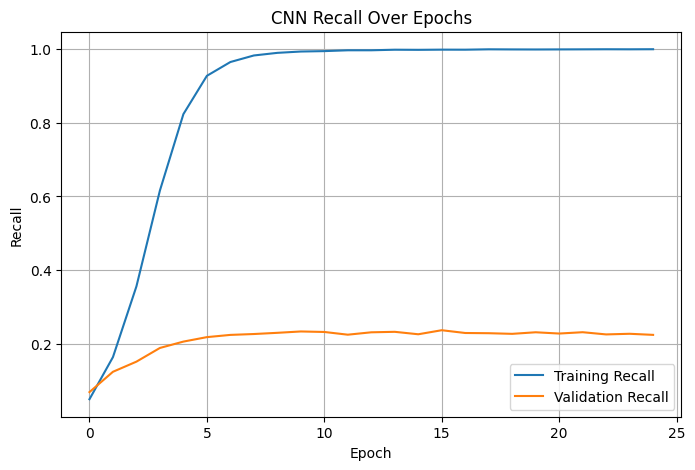

In [27]:
# CodeGrade Tag Ex4a-i
history = cnn_history.history
plt.figure(figsize=(8,5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history['precision'], label='Training Precision')
plt.plot(history['val_precision'], label='Validation Precision')
plt.title('CNN Precision Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history['recall'], label='Training Recall')
plt.plot(history['val_recall'], label='Validation Recall')
plt.title('CNN Recall Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()
#Complete here

* **Load the best weights from your model checkpoint, and create plots demonstrating the classification performance for all three classes. Include these plots in your report, and critically evaluate on the performance of the model across the classes.**

### 4.b. LSTM Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

In [ ]:
# CodeGrade Tag Ex4b-i
history = lstm_history.history
plt.figure(figsize=(8,5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
#Complete here

### 4.c. Produce examples for the report

* First, load the best weights from your checkpoints of both your models.

* Choose a few images from the dataset, plot them and print their captions. Use these examples of images and captions to demonstrate the classification performance of the CNN model on the images and of the LSTM model on their captions.

* Be sure to demonstrate the results of the multi-label classification. Compare, for each example image, the top three most probable sections predicted by the CNN and the top three most probable sections predicted by the LSTM, with the ground truth sections.

* Include these examples in your report, and critically evaluate on the performance of the model across the classes.

In [ ]:
# CodeGrade Tag Ex4c
cnn_model.load_weights(checkpoint_cnn_filepath)
lstm_model.load_weights(checkpoint_lstm_filepath)
example_indices = [0, 10, 25]
sections_list = list(sections_names)
def top3(pred):
    """Return top-3 labels and probabilities."""
    idx = np.argsort(pred)[::-1][:3]
    return [(sections_list[i], float(pred[i])) for i in idx]
for idx in example_indices:
  img_path = img_locs_test[idx]
  caption = captions_test[idx]
  true_label_idx = np.argmax(labels_test[idx])
  true_label = sections_list[true_label_idx]
  img = plt.imread(img_path)
  plt.figure(figsize=(5,4))
  plt.imshow(img)
  plt.axis("off")
  plt.title(f"Example Image (Index {idx})")
  plt.show()
  print("Caption:")
  print(caption)
  print()
  img_tensor = tf.expand_dims(parse_image(img_path, labels_test[idx])[0], axis=0)
  img_tensor = img_process(img_tensor, None)[0]
  cnn_pred = cnn_model.predict(img_tensor)[0]
  cnn_top3 = top3(cnn_pred)
  cap_ids = tf.cast(encoder(tf.constant([caption], dtype=tf.string)), tf.int32)
  lstm_pred = lstm_model.predict(cap_ids)[0]
  lstm_top3 = top3(lstm_pred)
  print("Ground truth section:", true_label)
  print("\nTop-3 CNN predictions:")
  for s, p in cnn_top3:
      print(f"  {s}: {p:.4f}")
  print("\nTop-3 LSTM predictions:")
  for s, p in lstm_top3:
      print(f"  {s}: {p:.4f}")
  print("\n" + "-"*50 + "\n")
#Complete here